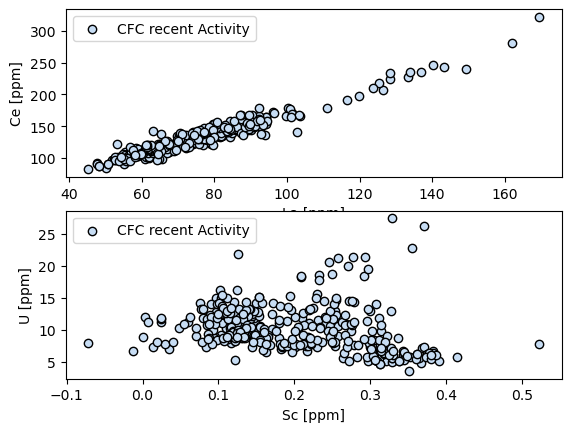

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari sheet 'Supp_traces' pada file Excel
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# Buat figure dengan dua subplot vertikal
fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
# Scatter plot antara La dan Ce
ax1.scatter(my_dataset.La, my_dataset.Ce, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
ax1.set_xlabel('La [ppm]')
ax1.set_ylabel('Ce [ppm]')
ax1.legend()

ax2 = fig.add_subplot(2,1,2)
# Scatter plot antara Sc dan U
ax2.scatter(my_dataset.Sc, my_dataset.U, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
ax2.set_xlabel('Sc [ppm]')

ax2.set_ylabel('U [ppm]')

ax2.legend()

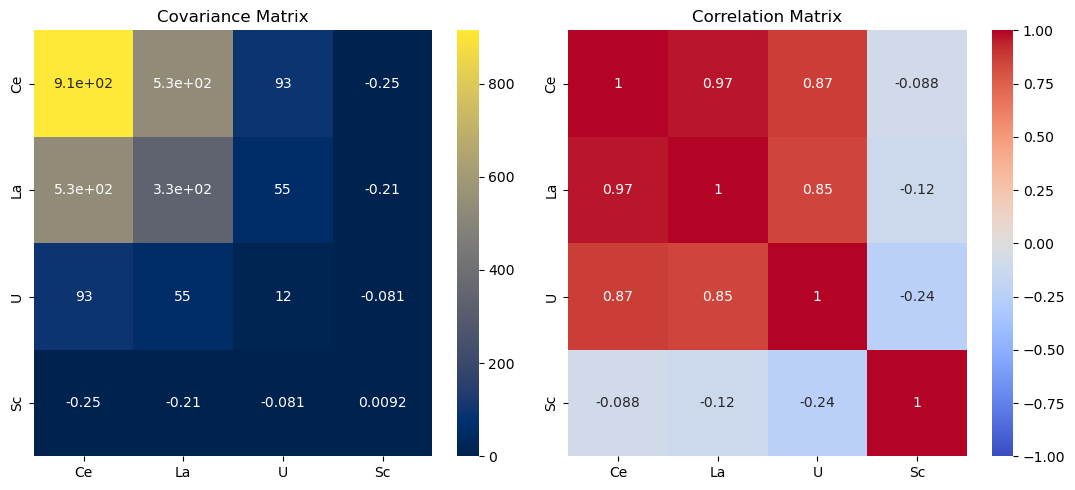

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca data dari sheet 'Supp_traces' pada file Excel
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# Ambil subset kolom untuk analisis kovarians dan korelasi
my_sub_dataset = my_dataset[['Ce','La','U','Sc']]

cov = my_sub_dataset.cov()
cor = my_sub_dataset.corr()

fig = plt.figure(figsize=(11,5))

ax1 = fig.add_subplot(1,2,1)
ax1.set_title('Covariance Matrix')
# Plot heatmap dari matriks kovarians
sns.heatmap(cov, annot=True, cmap='cividis', ax=ax1)

ax2 = fig.add_subplot(1,2,2)
ax2.set_title('Correlation Matrix')
# Plot heatmap dari matriks korelasi dengan rentang [-1, 1]
sns.heatmap(cor, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=ax2)



fig.tight_layout()

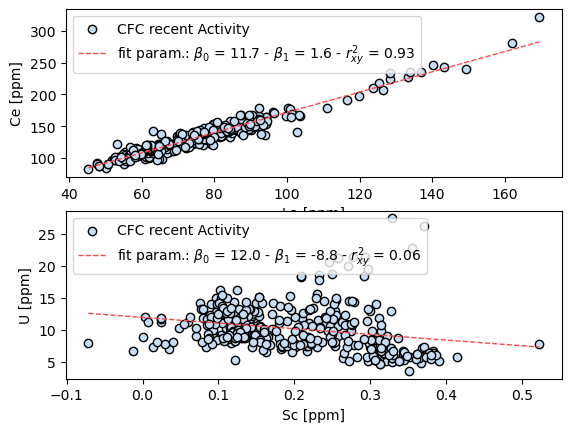

In [ ]:
import pandas as pd
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

# Baca data dari sheet 'Supp_traces' pada file Excel
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

fig = plt.figure()
ax1= fig.add_subplot(2,1,1)
# Scatter plot La vs Ce dengan regresi linear
ax1.scatter(my_dataset.La, my_dataset.Ce, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
b1, b0, rho_value, p_value, std_err = st.linregress(my_dataset.La, my_dataset.Ce)
# Buat garis regresi linear sesuai hasil fit
x = np.linspace(my_dataset.La.min(),my_dataset.La.max())
y = b0 + b1*x
ax1.plot(x, y, linewidth=1, color='#ff464a', linestyle='--', label=r"fit param.: $\beta_0$ = " + '{:.1f}'.format(b0) + r" - $\beta_1$ = "  + '{:.1f}'.format(b1) + r" - $r_{xy}^{2}$ = " + '{:.2f}'.format(rho_value**2))
ax1.set_xlabel('La [ppm]')
ax1.set_ylabel('Ce [ppm]')
ax1.legend(loc= 'upper left')

ax2 = fig.add_subplot(2,1,2)
# Scatter plot Sc vs U dengan regresi linear
ax2.scatter(my_dataset.Sc, my_dataset.U, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
b1, b0, rho_value, p_value, std_err = st.linregress(my_dataset.Sc, my_dataset.U)
# Buat garis regresi linear sesuai hasil fit
x = np.linspace(my_dataset.Sc.min(),my_dataset.Sc.max())
y = b0 + b1*x
ax2.plot(x, y, linewidth=1, color='#ff464a', linestyle='--', label=r"fit param.: $\beta_0$ = " + '{:.1f}'.format(b0) + r" - $\beta_1$ = "  + '{:.1f}'.format(b1) + r" - $r_{xy}^{2}$ = " + '{:.2f}'.format(rho_value**2))

ax2.set_xlabel('Sc [ppm]')

ax2.set_ylabel('U [ppm]')
ax2.legend(loc= 'upper left')

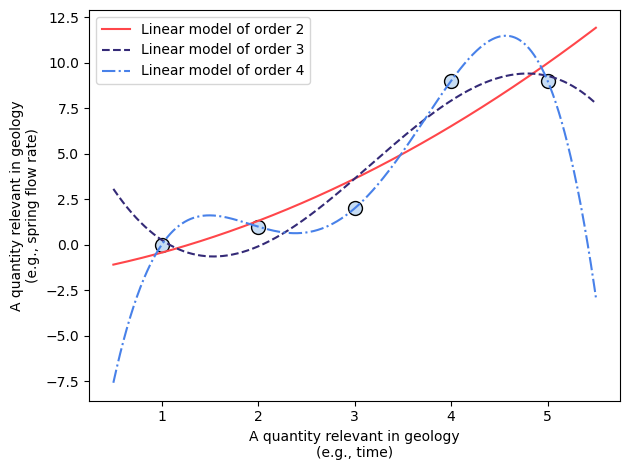

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data contoh untuk plot dan polinomial fitting
x = np.arange(1,6)
# Nilai y yang akan dicocokkan dengan polinomial
y = np.array([0,1,2,9,9])

fig, ax = plt.subplots()
# Plot titik data asli
ax.scatter(x, y, marker = 'o', s = 100, color = '#c7ddf4', edgecolor = 'k')

# Orde polinomial yang akan dicoba
orders = np.array([2,3,4])
# Warna untuk setiap garis polinomial
colors =['#ff464a','#342a77','#4881e9']
# Gaya garis untuk setiap model
linestiles = ['-','--','-.']

# Coba beberapa orde polinomial untuk melihat perbedaan kurva fit
for order, color, linestile in zip(orders, colors, linestiles):   
    # Hitung koefisien polinomial
    betas = np.polyfit(x, y, order)
    # Buat fungsi polinomial dari koefisien tersebut
    func = np.poly1d(betas)
    # Buat x yang halus untuk menggambar kurva
    x1 = np.linspace(0.5,5.5, 1000)
    # Hitung nilai y dari fungsi polinomial
    y1 = func(x1)
    # Plot kurva hasil fit untuk setiap orde
    ax.plot(x1, y1, color=color, linestyle=linestile, label="Linear model of order " + str(order))

# Tampilkan legenda yang menjelaskan setiap model
ax.legend()
# Label sumbu X dengan deskripsi singkat
ax.set_xlabel('A quantity relevant in geology\n(e.g., time)')
# Label sumbu Y dengan deskripsi singkat
ax.set_ylabel('A quantity relevant in geology\n(e.g., spring flow rate)') 

# Atur tata letak agar komponen tidak saling bertumpuk
fig.tight_layout()  

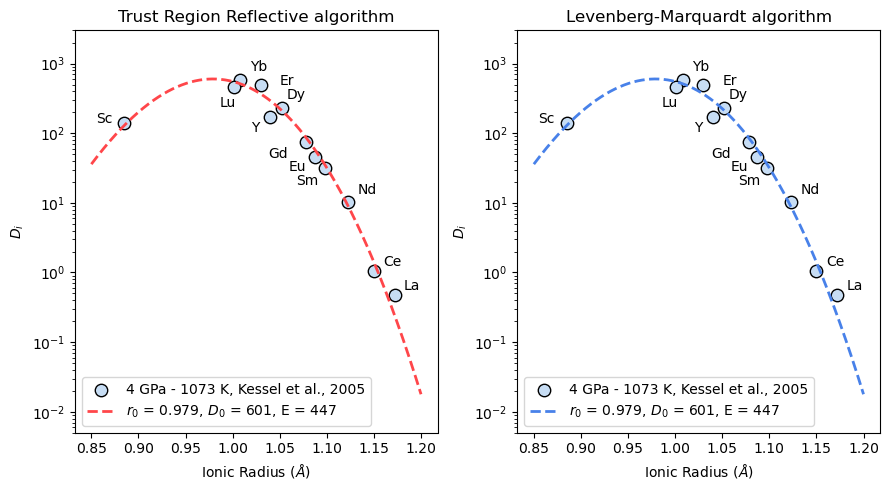

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fungsi model untuk fitting data Di terhadap ionic radius I_r
# Ini adalah ekspresi yang bergantung pada parameter r0, D0, dan E
def func(r, r0, D0, E): 
    R=8.314462618
    scale = 1e-21 # r in Angstrom (r^3 -> 10^-30 m), E is GPa (10^9 Pa)
    T = 800 + 273.15
    Na=6.02e23
    return D0*np.exp((-4*np.pi*E*Na*((r0/2)*(r-r0)**2+(1/3)*(r-r0)**3)*scale)/(R*T))

# Fungsi tambahan untuk memberi label nama unsur pada plot
def add_elements(ax):
    names = ['La', 'Ce', 'Nd', 'Sm', 'Eu', 'Gd', 'Dy', 'Er', 'Yb', 'Lu', 'Y', 'Sc']
    annotate_xs = np.array([1.172 + 0.01, 1.15 + 0.01, 1.123 + 0.01, 1.098 - 0.031, 1.087 - 0.028, 1.078 - 0.04, 1.052 + 0.005, 1.03 + 0.02, 1.008 + 0.01, 1.001 - 0.015, 1.04 -0.02, 0.885 - 0.03])
    annotate_ys = np.array([0.468 + 0.1, 1.050 + 0.2, 10.305 + 3, 31.283 - 13, 45.634 -17, 74.633- 30, 229.279 + 80, 485.500, 583.828 +200, 460.404 -220, 172.844 -70, 141.630])
    
    for name, annotate_x, annotate_y in zip(names, annotate_xs, annotate_ys):
        ax.annotate(name, (annotate_x, annotate_y))

# Data observasi: Di dan ionic radius I_r
Di = np.array([0.468, 1.050, 10.305, 31.283, 45.634, 74.633, 229.279, 485.500, 583.828, 460.404, 172.844, 141.630])
I_r = np.array([1.172, 1.15, 1.123, 1.098, 1.087, 1.078, 1.052, 1.03, 1.008, 1.001, 1.04, 0.885])

fig = plt.figure(figsize=(9,5))

# Plot hasil fitting dengan metode Trust Region Reflective
ax1 = fig.add_subplot(1,2,1)
ax1.set_title("Trust Region Reflective algorithm")
# Plot data observasi pada subplot pertama
ax1.scatter(I_r, Di, s=80, color='#c7ddf4', edgecolors='k', label='4 GPa - 1073 K, Kessel et al., 2005')

# Jalankan fitting kurva menggunakan model func dengan batas parameter
popt1, pcov1 = curve_fit(func, I_r, Di, method='trf', bounds=([0.8,0,0],[1.3,1000,1000]))

# Buat garis model berdasarkan parameter hasil fitting
x1 = np.linspace(0.85,1.2,1000)
y1 = func(x1,popt1[0],popt1[1], popt1[2])
# Gambar kurva hasil fitting model
ax1.plot(x1, y1, color='#ff464a', linewidth=2, linestyle ='--', label=r'$r_0$ = ' + '{:.3f}'.format(popt1[0]) + r', $D_0$ = ' + '{:.0f}'.format(popt1[1]) + ', E = ' + '{:.0f}'.format(popt1[2]))
# Tambahkan anotasi unsur pada subplot pertama
add_elements(ax = ax1)
ax1.set_yscale('log')
ax1.set_xlabel(r'Ionic Radius ($\AA$)')
ax1.set_ylabel(r'$D_i$')
ax1.set_ylim(0.005,3000)
ax1.legend()

# Plot hasil fitting dengan metode Levenberg-Marquardt
ax2 = fig.add_subplot(1,2,2)
ax2.set_title("Levenberg-Marquardt algorithm")
# Plot data observasi pada subplot kedua
ax2.scatter(I_r, Di, s=80, color='#c7ddf4', edgecolors='k', label='4 GPa - 1073 K, Kessel et al., 2005')

# Fitting dengan metode alternatif: Levenberg-Marquardt
popt2, pcov2 = curve_fit(func, I_r, Di, method='lm', p0=(1.1,100,100))

# Buat garis model untuk hasil fitting kedua
x2 = np.linspace(0.85,1.2,1000)
y2 = func(x2,popt2[0],popt2[1], popt2[2])
# Gambar kurva hasil fitting metode Levenberg-Marquardt
ax2.plot(x2, y2, color='#4881e9', linewidth=2, linestyle ='--', label=r'$r_0$ = ' + '{:.3f}'.format(popt2[0]) + r', $D_0$ = ' + '{:.0f}'.format(popt2[1]) + ', E = ' + '{:.0f}'.format(popt2[2]))
# Tambahkan anotasi unsur pada subplot kedua
add_elements(ax = ax2)
ax2.set_yscale('log')
ax2.set_xlabel(r'Ionic Radius ($\AA$)')
ax2.set_ylabel(r'$D_i$')
ax2.set_ylim(0.005,3000)
ax2.legend()

# Sesuaikan tata letak agar plot tidak saling tumpang tindih
fig.tight_layout()